In [3]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

BASE_DIR = Path.cwd()
PROJECT_ROOT = BASE_DIR.parent if BASE_DIR.name == 'noteboods' else BASE_DIR
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PATH = ARTIFACT_DIR / 'metadata.json'

MODEL_SLUGS = {
    'Logistic Regression': 'logistic_regression',
    'Random Forest': 'random_forest',
    'LightGBM': 'lightgbm',
    'XGBoost': 'xgboost',
    'CatBoost': 'catboost',
}
MODEL_FILE_NAMES = {
    'Logistic Regression': 'best_logistic_model.joblib',
    'Random Forest': 'best_random_forest_model.joblib',
    'LightGBM': 'best_lightgbm_model.joblib',
    'XGBoost': 'best_xgboost_model.joblib',
    'CatBoost': 'best_catboost_model.cbm',
}

## 1. Objective and Modeling Framing

This notebook predicts whether a reported Chicago crime incident in Chicago results in an arrest. The modeling goal is **out-of-time generalization** rather than fitting the arrest rate of the same calendar year.

The evaluation design is intentionally locked before model fitting. `Year` is **not** used as a predictor. Instead, `Year` is reserved for temporal splitting, rolling validation, and stratified sampling. Hyperparameters are chosen by **validation PR-AUC**, which is the most appropriate primary metric because arrest outcomes are relatively rare and the data are therefore imbalanced. Threshold selection is separated from hyperparameter tuning: each final model uses the threshold chosen on the validation window, and that threshold is then carried unchanged into the test evaluation.

In [4]:
usecols = [
    'Arrest', 'Year', 'Month', 'DayOfWeek', 'Hour',
    'Primary Type', 'Location Description', 'Domestic', 'Community Area'
]

df = pd.read_csv(DATA_DIR / 'df.csv', usecols=usecols)
TARGET = 'Arrest'
YEAR_COL = 'Year'
BASE_FEATURES = ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Domestic', 'Community Area']
CAT_FEATURES = ['Primary Type', 'Location Description', 'Community Area']
TRAIN_YEARS = list(range(2016, 2022))
VAL_YEARS = [2022, 2023]
TEST_YEARS = [2024, 2025]
ROLLING_HOLDOUT_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TUNING_ROWS = 200_000
FINAL_TRAIN_ROWS = 800_000
SHAP_SAMPLE_ROWS = 10_000
RANDOM_STATE = 42
TIME_BUDGET_SECONDS = 600
TRIAL_BUDGETS = {
    'Logistic Regression': {'n_trials': 12, 'timeout': 240},
    'Random Forest': {'n_trials': 12, 'timeout': 300},
    'LightGBM': {'n_trials': 24, 'timeout': 420},
    'XGBoost': {'n_trials': 24, 'timeout': 420},
    'CatBoost': {'n_trials': 24, 'timeout': 420},
}
MODEL_SAMPLE_FALLBACKS = {
    'Logistic Regression': [800_000, 500_000],
    'Random Forest': [800_000, 500_000, 300_000],
    'LightGBM': [800_000, 500_000],
    'XGBoost': [800_000, 500_000],
    'CatBoost': [800_000, 500_000, 300_000],
}

for col in ['Month', 'DayOfWeek', 'Hour', 'Community Area']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int32')
df[TARGET] = df[TARGET].astype(int)
df['Domestic'] = df['Domestic'].astype(int)
df['Primary Type'] = df['Primary Type'].astype(str)
df['Location Description'] = df['Location Description'].astype(str)
df = df.dropna(subset=BASE_FEATURES + [TARGET, YEAR_COL]).copy()
df['Community Area'] = df['Community Area'].astype(int).astype(str)

train_full = df[df[YEAR_COL].isin(TRAIN_YEARS)].copy()
val_full = df[df[YEAR_COL].isin(VAL_YEARS)].copy()
test_full = df[df[YEAR_COL].isin(TEST_YEARS)].copy()
print(f'Train rows (2016-2021): {len(train_full):,}')
print(f'Validation rows (2022-2023): {len(val_full):,}')
print(f'Test rows (2024-2025): {len(test_full):,}')

Train rows (2016-2021): 1,492,382
Validation rows (2022-2023): 503,295
Test rows (2024-2025): 495,991


## 2. Data Preparation and Evaluation Protocol

The modeling sample is defined once and then reused throughout the notebook. The final analytic dataset includes complete cases for the selected predictors and target, with `Community Area` retained as a categorical spatial variable. The time split follows a genuinely forward-looking design: the training window covers 2016-2021, validation covers 2022-2023, and the final test window covers 2024-2025.

This structure matters because arrest patterns shift over time. A random split would overstate model performance by mixing older and newer reporting environments. The current design therefore asks a more policy-relevant question: whether relationships learned from earlier years remain useful for later years.

In [5]:
def stratified_sample(data, target_rows, strata_cols=(YEAR_COL, TARGET), random_state=RANDOM_STATE):
    if len(data) <= target_rows:
        return data.copy().reset_index(drop=True)
    fraction = target_rows / len(data)
    pieces = []
    for _, group in data.groupby(list(strata_cols), observed=True, sort=False):
        take = max(1, int(round(len(group) * fraction)))
        take = min(take, len(group))
        pieces.append(group.sample(n=take, random_state=random_state))
    sampled = pd.concat(pieces).sort_index()
    if len(sampled) > target_rows:
        sampled = sampled.sample(n=target_rows, random_state=random_state)
    elif len(sampled) < target_rows:
        remainder = data.drop(sampled.index, errors='ignore')
        if not remainder.empty:
            extra = min(target_rows - len(sampled), len(remainder))
            sampled = pd.concat([sampled, remainder.sample(n=extra, random_state=random_state)])
    return sampled.reset_index(drop=True)


def choose_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5
    f1_values = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
    return float(thresholds[int(np.nanargmax(f1_values))])


def evaluate_at_threshold(y_true, scores, threshold, model_name, split_name, training_rows, imbalance_setting):
    preds = (scores >= threshold).astype(int)
    return {
        'Model': model_name,
        'Split': split_name,
        'Threshold': float(threshold),
        'Training Rows': int(training_rows),
        'Imbalance Handling': imbalance_setting,
        'ROC-AUC': roc_auc_score(y_true, scores),
        'PR-AUC': average_precision_score(y_true, scores),
        'F1': f1_score(y_true, preds, zero_division=0),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall': recall_score(y_true, preds, zero_division=0),
    }


def prepare_typed_frame(frame, features):
    out = frame[features].copy()
    for col in ['Month', 'DayOfWeek', 'Hour']:
        if col in out:
            out[col] = out[col].astype(int)
    if 'Domestic' in out:
        out['Domestic'] = out['Domestic'].astype(int)
    if 'Primary Type' in out:
        out['Primary Type'] = out['Primary Type'].astype(str)
    if 'Location Description' in out:
        out['Location Description'] = out['Location Description'].astype(str)
    if 'Community Area' in out:
        out['Community Area'] = out['Community Area'].astype(str)
    return out


def prepare_lgb_frame(frame, features):
    out = prepare_typed_frame(frame, features)
    for col in CAT_FEATURES:
        if col in out:
            out[col] = out[col].astype('category')
    return out


def get_category_maps(reference_frame):
    maps = {}
    for col in ['Primary Type', 'Location Description']:
        values = sorted(reference_frame[col].astype(str).unique())
        maps[col] = {value: idx for idx, value in enumerate(values)}
    return maps


def prepare_xgb_frame(frame, features, category_maps):
    out = prepare_typed_frame(frame, features)
    for col, mapping in category_maps.items():
        if col in out:
            out[col] = out[col].map(mapping).fillna(-1).astype(int)
    if 'Community Area' in out:
        out['Community Area'] = out['Community Area'].astype(int)
    return out


def prepare_cat_frame(frame, features):
    return prepare_typed_frame(frame, features)


def sanitize_logistic_params(params):
    return {'C': float(params['C']), 'class_weight': None if params['class_weight'] == 'None' else params['class_weight']}


def sanitize_rf_params(params):
    return {
        'n_estimators': int(params['n_estimators']),
        'max_depth': None if params.get('use_none_max_depth', False) else int(params['max_depth']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'max_features': params['max_features'] if params['max_features'] == 'sqrt' else float(params['max_features']),
        'class_weight': None if params['class_weight'] == 'None' else params['class_weight'],
    }


def sanitize_lgb_params(params):
    return {
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples']),
        'learning_rate': float(params['learning_rate']),
        'n_estimators': int(params['n_estimators']),
        'subsample': float(params['subsample']),
        'colsample_bytree': float(params['colsample_bytree']),
        'reg_lambda': float(params['reg_lambda']),
        'scale_pos_weight': float(params['scale_pos_weight']),
    }


def sanitize_xgb_params(params):
    return {
        'max_depth': int(params['max_depth']),
        'min_child_weight': int(params['min_child_weight']),
        'learning_rate': float(params['learning_rate']),
        'n_estimators': int(params['n_estimators']),
        'subsample': float(params['subsample']),
        'colsample_bytree': float(params['colsample_bytree']),
        'gamma': float(params['gamma']),
        'reg_lambda': float(params['reg_lambda']),
        'scale_pos_weight': float(params['scale_pos_weight']),
    }


def sanitize_cat_params(params):
    return {
        'depth': int(params['depth']),
        'learning_rate': float(params['learning_rate']),
        'iterations': int(params['iterations']),
        'l2_leaf_reg': float(params['l2_leaf_reg']),
        'auto_class_weights': None if params['auto_class_weights'] == 'None' else params['auto_class_weights'],
    }


def fit_final_with_fallback(model_name, build_fn, params, train_data, fit_fn, validation_payload):
    attempts = []
    artifact = None
    for rows in MODEL_SAMPLE_FALLBACKS[model_name]:
        sample_rows = min(rows, len(train_data))
        sample = stratified_sample(train_data, sample_rows)
        start = time.time()
        model = build_fn(params)
        fit_fn(model, sample, validation_payload)
        elapsed = time.time() - start
        attempts.append({'Training Rows': len(sample), 'Seconds': elapsed})
        artifact = {'model': model, 'training_rows': len(sample), 'seconds': elapsed}
        if elapsed <= TIME_BUDGET_SECONDS or rows == MODEL_SAMPLE_FALLBACKS[model_name][-1]:
            break
    return artifact, pd.DataFrame(attempts)


def load_metadata():
    if METADATA_PATH.exists():
        return json.loads(METADATA_PATH.read_text())
    return {}


def save_metadata(metadata):
    METADATA_PATH.write_text(json.dumps(metadata, indent=2))


def update_root_metadata(payload):
    metadata = load_metadata()
    metadata.update(payload)
    save_metadata(metadata)
    return metadata


def update_model_metadata(model_name, payload):
    metadata = load_metadata()
    metadata.setdefault('models', {})[model_name] = payload
    save_metadata(metadata)
    return metadata


def update_section_metadata(section_name, payload):
    metadata = load_metadata()
    metadata.setdefault('sections', {})[section_name] = payload
    save_metadata(metadata)
    return metadata


def model_artifact_path(model_name):
    return ARTIFACT_DIR / MODEL_FILE_NAMES[model_name]


def frame_path(name):
    return ARTIFACT_DIR / name


def save_frame(df_obj, path):
    df_obj.to_csv(path, index=False)


def load_frame(path):
    return pd.read_csv(path)


def save_model_artifact(model_name, model):
    path = model_artifact_path(model_name)
    if model_name == 'CatBoost':
        model.save_model(path)
    else:
        joblib.dump(model, path)


def load_model_artifact(model_name):
    path = model_artifact_path(model_name)
    if model_name == 'CatBoost':
        model = CatBoostClassifier()
        model.load_model(path)
        return model
    return joblib.load(path)


def cache_ready(model_name, extra_paths=None):
    extra_paths = extra_paths or []
    required = [model_artifact_path(model_name)] + [Path(p) for p in extra_paths]
    return all(path.exists() for path in required)


category_maps = get_category_maps(df)
tuning_sample = stratified_sample(train_full, TUNING_ROWS)
refit_sample_preview = stratified_sample(train_full, FINAL_TRAIN_ROWS)

split_summary = pd.DataFrame([
    {'Split': 'Train (full)', 'Years': '2016-2021', 'Rows': len(train_full), 'Arrest Rate': train_full[TARGET].mean()},
    {'Split': 'Train (tuning sample)', 'Years': '2016-2021', 'Rows': len(tuning_sample), 'Arrest Rate': tuning_sample[TARGET].mean()},
    {'Split': 'Train (final target)', 'Years': '2016-2021', 'Rows': len(refit_sample_preview), 'Arrest Rate': refit_sample_preview[TARGET].mean()},
    {'Split': 'Validation', 'Years': '2022-2023', 'Rows': len(val_full), 'Arrest Rate': val_full[TARGET].mean()},
    {'Split': 'Test', 'Years': '2024-2025', 'Rows': len(test_full), 'Arrest Rate': test_full[TARGET].mean()},
])
split_summary['Rows'] = split_summary['Rows'].map(lambda x: f'{x:,}')
split_summary['Arrest Rate'] = split_summary['Arrest Rate'].map(lambda x: f'{x:.2%}')
display(split_summary)
display(pd.DataFrame({'Main Model Features': BASE_FEATURES}))

base_scale_pos_weight = (1 - train_full[TARGET].mean()) / train_full[TARGET].mean()
X_tune_base = prepare_typed_frame(tuning_sample, BASE_FEATURES)
y_tune = tuning_sample[TARGET].astype(int)
X_val_base = prepare_typed_frame(val_full, BASE_FEATURES)
y_val = val_full[TARGET].astype(int)
X_test_base = prepare_typed_frame(test_full, BASE_FEATURES)
y_test = test_full[TARGET].astype(int)
X_val_lgb = prepare_lgb_frame(val_full, BASE_FEATURES)
X_test_lgb = prepare_lgb_frame(test_full, BASE_FEATURES)
X_val_xgb = prepare_xgb_frame(val_full, BASE_FEATURES, category_maps)
X_test_xgb = prepare_xgb_frame(test_full, BASE_FEATURES, category_maps)
X_val_cat = prepare_cat_frame(val_full, BASE_FEATURES)
X_test_cat = prepare_cat_frame(test_full, BASE_FEATURES)
cat_feature_indices = [BASE_FEATURES.index(col) for col in CAT_FEATURES]

metadata = update_root_metadata({
    'artifact_version': 1,
    'feature_config': {
        'base_features': BASE_FEATURES,
        'cat_features': CAT_FEATURES,
        'cat_feature_indices': cat_feature_indices,
        'category_maps': category_maps,
    },
    'split_config': {
        'train_years': TRAIN_YEARS,
        'validation_years': VAL_YEARS,
        'test_years': TEST_YEARS,
        'tuning_rows': TUNING_ROWS,
        'final_train_rows': FINAL_TRAIN_ROWS,
        'shap_sample_rows': SHAP_SAMPLE_ROWS,
        'random_state': RANDOM_STATE,
    },
})

,Split,Years,Rows,Arrest Rate
0,Train (full),2016-2021,"1,492,382",18.55%
1,Train (tuning sample),2016-2021,"200,000",18.55%
2,Train (final target),2016-2021,"800,000",18.55%
3,Validation,2022-2023,"503,295",12.00%
4,Test,2024-2025,"495,991",14.86%


,Main Model Features
0,Month
1,DayOfWeek
2,Hour
3,Primary Type
4,Location Description
5,Domestic
6,Community Area


## 3. Class Imbalance Strategy

The overall arrest rate is low enough that class imbalance must be treated as a central modeling issue rather than a minor adjustment. For that reason, **PR-AUC** is the primary selection metric throughout the notebook. ROC-AUC is still reported because it remains informative about ranking quality, but PR-AUC is more sensitive to performance on the minority class and therefore better aligned with the substantive prediction task.

Imbalance handling and threshold choice are also separated on purpose. Class weighting or related settings affect how the model learns, whereas the threshold determines how predicted probabilities are converted into class labels. Keeping those two decisions separate makes the final comparisons more interpretable.

## 4. Logistic Regression

Logistic Regression serves as the linear baseline. It provides a transparent benchmark for whether the main signal in the data can be captured through additive effects after categorical encoding.

In [6]:
def build_logistic_model(params):
    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ]), ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Community Area']),
        ('bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), ['Domestic']),
    ])
    model = LogisticRegression(
        C=params['C'],
        class_weight=params['class_weight'],
        max_iter=600,
        solver='saga',
        penalty='l2',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    return Pipeline([('preprocess', preprocessor), ('model', model)])


def logistic_objective(trial):
    params = sanitize_logistic_params({
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'class_weight': trial.suggest_categorical('class_weight', ['None', 'balanced']),
    })
    model = build_logistic_model(params)
    model.fit(X_tune_base, y_tune)
    val_scores = model.predict_proba(X_val_base)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


logistic_tuning_path = frame_path('logistic_regression_tuning.csv')
logistic_results_path = frame_path('logistic_regression_results.csv')
logistic_attempts_path = frame_path('logistic_regression_attempts.csv')
logistic_meta = load_metadata().get('models', {}).get('Logistic Regression', {})

if cache_ready('Logistic Regression', [logistic_tuning_path, logistic_results_path, logistic_attempts_path]) and logistic_meta:
    best_logistic_model = load_model_artifact('Logistic Regression')
    logistic_tuning = load_frame(logistic_tuning_path)
    logistic_results = load_frame(logistic_results_path)
    logistic_attempts = load_frame(logistic_attempts_path)
    best_logistic_params = logistic_meta['best_params']
    logistic_training_rows = int(logistic_meta['training_rows'])
    logistic_threshold = float(logistic_meta['threshold'])
else:
    logistic_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    logistic_study.optimize(logistic_objective, **TRIAL_BUDGETS['Logistic Regression'])
    logistic_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in logistic_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_logistic_params = sanitize_logistic_params(logistic_study.best_trial.params)

    def logistic_fit_fn(model, sample, validation_payload):
        model.fit(prepare_typed_frame(sample, BASE_FEATURES), sample[TARGET].astype(int))

    logistic_artifact, logistic_attempts = fit_final_with_fallback(
        'Logistic Regression',
        build_logistic_model,
        best_logistic_params,
        train_full,
        logistic_fit_fn,
        None,
    )
    best_logistic_model = logistic_artifact['model']
    logistic_training_rows = logistic_artifact['training_rows']
    logistic_val_scores = best_logistic_model.predict_proba(X_val_base)[:, 1]
    logistic_threshold = choose_threshold(y_val, logistic_val_scores)
    logistic_test_scores = best_logistic_model.predict_proba(X_test_base)[:, 1]
    logistic_results = pd.DataFrame([
        evaluate_at_threshold(y_val, logistic_val_scores, logistic_threshold, 'Logistic Regression', 'Validation', logistic_training_rows, f"class_weight={best_logistic_params['class_weight']}"),
        evaluate_at_threshold(y_test, logistic_test_scores, logistic_threshold, 'Logistic Regression', 'Test', logistic_training_rows, f"class_weight={best_logistic_params['class_weight']}"),
    ])

    save_model_artifact('Logistic Regression', best_logistic_model)
    save_frame(logistic_tuning, logistic_tuning_path)
    save_frame(logistic_results, logistic_results_path)
    save_frame(logistic_attempts, logistic_attempts_path)
    metadata = update_model_metadata('Logistic Regression', {
        'best_params': best_logistic_params,
        'threshold': float(logistic_threshold),
        'training_rows': int(logistic_training_rows),
        'model_file': MODEL_FILE_NAMES['Logistic Regression'],
        'tuning_file': logistic_tuning_path.name,
        'results_file': logistic_results_path.name,
        'attempts_file': logistic_attempts_path.name,
    })

display(logistic_tuning.head(10))
display(logistic_attempts)
display(logistic_results)

,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,C,class_weight
11,11,0.568475,0.836508,0.515769,1.414725,None
1,1,0.568421,0.836788,0.515749,0.248104,None
4,4,0.568419,0.836401,0.515728,2.136833,None
10,10,0.568190,0.836110,0.515738,6.521703,None
9,9,0.568033,0.836612,0.516039,0.114009,None
8,8,0.567252,0.836291,0.515928,0.066724,None
0,0,0.565354,0.835572,0.515505,0.031489,None
3,3,0.560138,0.838633,0.513304,0.679658,balanced
6,6,0.557450,0.838451,0.513819,0.053429,balanced
5,5,0.549701,0.835670,0.506663,0.005415,balanced


,Training Rows,Seconds
0,800000,5.804306


,Model,Split,Threshold,Training Rows,Imbalance Handling,ROC-AUC,PR-AUC,F1,Precision,Recall
0,Logistic Regression,Validation,0.371541,800000,class_weight=None,0.837578,0.570138,0.515432,0.582789,0.462031
1,Logistic Regression,Test,0.371541,800000,class_weight=None,0.832468,0.586297,0.511854,0.622781,0.434468


## 5. Random Forest

Random Forest provides a non-linear ensemble benchmark. It is useful for testing whether interaction structure and threshold effects improve on the linear baseline without relying on boosting-specific optimization.

In [7]:
def build_rf_model(params):
    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Community Area']),
        ('bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), ['Domestic']),
    ])
    model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        class_weight=params['class_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return Pipeline([('preprocess', preprocessor), ('model', model)])


def rf_objective(trial):
    use_none = trial.suggest_categorical('use_none_max_depth', [False, True])
    params = sanitize_rf_params({
        'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=100),
        'use_none_max_depth': use_none,
        'max_depth': 12 if use_none else trial.suggest_int('max_depth', 8, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50, step=5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.3, 0.5, 0.8]),
        'class_weight': trial.suggest_categorical('class_weight', ['None', 'balanced_subsample']),
    })
    model = build_rf_model(params)
    model.fit(X_tune_base, y_tune)
    val_scores = model.predict_proba(X_val_base)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


rf_tuning_path = frame_path('random_forest_tuning.csv')
rf_results_path = frame_path('random_forest_results.csv')
rf_attempts_path = frame_path('random_forest_attempts.csv')
rf_meta = load_metadata().get('models', {}).get('Random Forest', {})

if cache_ready('Random Forest', [rf_tuning_path, rf_results_path, rf_attempts_path]) and rf_meta:
    best_rf_model = load_model_artifact('Random Forest')
    rf_tuning = load_frame(rf_tuning_path)
    rf_results = load_frame(rf_results_path)
    rf_attempts = load_frame(rf_attempts_path)
    best_rf_params = rf_meta['best_params']
    rf_training_rows = int(rf_meta['training_rows'])
    rf_threshold = float(rf_meta['threshold'])
else:
    rf_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    rf_study.optimize(rf_objective, **TRIAL_BUDGETS['Random Forest'])
    rf_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in rf_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_rf_params = sanitize_rf_params(rf_study.best_trial.params)

    def rf_fit_fn(model, sample, validation_payload):
        model.fit(prepare_typed_frame(sample, BASE_FEATURES), sample[TARGET].astype(int))

    rf_artifact, rf_attempts = fit_final_with_fallback(
        'Random Forest',
        build_rf_model,
        best_rf_params,
        train_full,
        rf_fit_fn,
        None,
    )
    best_rf_model = rf_artifact['model']
    rf_training_rows = rf_artifact['training_rows']
    rf_val_scores = best_rf_model.predict_proba(X_val_base)[:, 1]
    rf_threshold = choose_threshold(y_val, rf_val_scores)
    rf_test_scores = best_rf_model.predict_proba(X_test_base)[:, 1]
    rf_results = pd.DataFrame([
        evaluate_at_threshold(y_val, rf_val_scores, rf_threshold, 'Random Forest', 'Validation', rf_training_rows, f"class_weight={best_rf_params['class_weight']}"),
        evaluate_at_threshold(y_test, rf_test_scores, rf_threshold, 'Random Forest', 'Test', rf_training_rows, f"class_weight={best_rf_params['class_weight']}"),
    ])

    save_model_artifact('Random Forest', best_rf_model)
    save_frame(rf_tuning, rf_tuning_path)
    save_frame(rf_results, rf_results_path)
    save_frame(rf_attempts, rf_attempts_path)
    metadata = update_model_metadata('Random Forest', {
        'best_params': best_rf_params,
        'threshold': float(rf_threshold),
        'training_rows': int(rf_training_rows),
        'model_file': MODEL_FILE_NAMES['Random Forest'],
        'tuning_file': rf_tuning_path.name,
        'results_file': rf_results_path.name,
        'attempts_file': rf_attempts_path.name,
    })

display(rf_tuning.head(10))
display(rf_attempts)
display(rf_results)

,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,use_none_max_depth,n_estimators,min_samples_leaf,max_features,class_weight,max_depth
1,1,0.604545,0.854598,0.547080,True,600,15,0.8,None,NaN
10,10,0.604501,0.855427,0.548324,True,200,20,0.8,None,NaN
11,11,0.604501,0.855427,0.548324,True,200,20,0.8,None,NaN
0,0,0.602542,0.856661,0.548265,True,500,30,0.8,balanced_subsample,NaN
7,7,0.595365,0.848835,0.543578,True,500,5,0.5,None,NaN
4,4,0.595142,0.852631,0.542406,True,300,35,0.5,None,NaN
5,5,0.594594,0.846465,0.542698,False,400,5,0.8,balanced_subsample,29.0
9,9,0.594430,0.853165,0.538612,False,400,5,0.5,balanced_subsample,17.0
3,3,0.588221,0.852906,0.536943,False,600,45,0.5,balanced_subsample,30.0
8,8,0.574633,0.842359,0.532791,True,500,35,sqrt,None,NaN


,Training Rows,Seconds
0,800000,151.3837


,Model,Split,Threshold,Training Rows,Imbalance Handling,ROC-AUC,PR-AUC,F1,Precision,Recall
0,Random Forest,Validation,0.431366,800000,class_weight=None,0.858028,0.612715,0.555898,0.664122,0.478003
1,Random Forest,Test,0.431366,800000,class_weight=None,0.849394,0.624017,0.554357,0.688118,0.464135


## 6. LightGBM

LightGBM is the first boosting model and one of the main candidates for the final production-style benchmark. It is well suited to mixed categorical structure and can capture non-linear interactions more efficiently than the baseline models.

In [17]:
def build_lgb_model(params):
    return lgb.LGBMClassifier(
        objective='binary',
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        num_leaves=params['num_leaves'],
        min_child_samples=params['min_child_samples'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_lambda=params['reg_lambda'],
        scale_pos_weight=params['scale_pos_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def lgb_objective(trial):
    params = sanitize_lgb_params({
        'num_leaves': trial.suggest_int('num_leaves', 16, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.7 * base_scale_pos_weight, 1.8 * base_scale_pos_weight),
    })
    model = build_lgb_model(params)
    X_tune_lgb = prepare_lgb_frame(tuning_sample, BASE_FEATURES)
    model.fit(
        X_tune_lgb,
        y_tune,
        categorical_feature=CAT_FEATURES,
        eval_set=[(X_val_lgb, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    val_scores = model.predict_proba(X_val_lgb)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


lgb_tuning_path = frame_path('lightgbm_tuning.csv')
lgb_results_path = frame_path('lightgbm_results.csv')
lgb_attempts_path = frame_path('lightgbm_attempts.csv')
lgb_meta = load_metadata().get('models', {}).get('LightGBM', {})

if cache_ready('LightGBM', [lgb_tuning_path, lgb_results_path, lgb_attempts_path]) and lgb_meta:
    best_lgb_model = load_model_artifact('LightGBM')
    lgb_tuning = load_frame(lgb_tuning_path)
    lgb_results = load_frame(lgb_results_path)
    lgb_attempts = load_frame(lgb_attempts_path)
    best_lgb_params = lgb_meta['best_params']
    lgb_training_rows = int(lgb_meta['training_rows'])
    lgb_threshold = float(lgb_meta['threshold'])
else:
    lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    lgb_study.optimize(lgb_objective, **TRIAL_BUDGETS['LightGBM'])
    lgb_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in lgb_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_lgb_params = sanitize_lgb_params(lgb_study.best_trial.params)

    def lgb_fit_fn(model, sample, validation_payload):
        model.fit(
            prepare_lgb_frame(sample, BASE_FEATURES),
            sample[TARGET].astype(int),
            categorical_feature=CAT_FEATURES,
            eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )

    lgb_artifact, lgb_attempts = fit_final_with_fallback(
        'LightGBM',
        build_lgb_model,
        best_lgb_params,
        train_full,
        lgb_fit_fn,
        {'X_val': X_val_lgb, 'y_val': y_val},
    )
    best_lgb_model = lgb_artifact['model']
    lgb_training_rows = lgb_artifact['training_rows']
    lgb_val_scores = best_lgb_model.predict_proba(X_val_lgb)[:, 1]
    lgb_threshold = choose_threshold(y_val, lgb_val_scores)
    lgb_test_scores = best_lgb_model.predict_proba(X_test_lgb)[:, 1]
    lgb_results = pd.DataFrame([
        evaluate_at_threshold(y_val, lgb_val_scores, lgb_threshold, 'LightGBM', 'Validation', lgb_training_rows, f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}"),
        evaluate_at_threshold(y_test, lgb_test_scores, lgb_threshold, 'LightGBM', 'Test', lgb_training_rows, f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}"),
    ])

    save_model_artifact('LightGBM', best_lgb_model)
    save_frame(lgb_tuning, lgb_tuning_path)
    save_frame(lgb_results, lgb_results_path)
    save_frame(lgb_attempts, lgb_attempts_path)
    metadata = update_model_metadata('LightGBM', {
        'best_params': best_lgb_params,
        'threshold': float(lgb_threshold),
        'training_rows': int(lgb_training_rows),
        'model_file': MODEL_FILE_NAMES['LightGBM'],
        'tuning_file': lgb_tuning_path.name,
        'results_file': lgb_results_path.name,
        'attempts_file': lgb_attempts_path.name,
    })

display(lgb_tuning.head(10))
display(lgb_attempts)
display(lgb_results)

,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,num_leaves,min_child_samples,learning_rate,n_estimators,subsample,colsample_bytree,reg_lambda,scale_pos_weight
0,22,0.608120,0.857450,0.550215,233,11,0.022012,300,0.961171,0.788112,0.009498,3.074395
1,11,0.606939,0.857044,0.549472,227,10,0.023074,300,0.989529,0.767394,0.001170,3.125954
2,10,0.606307,0.856967,0.550109,229,10,0.027143,300,0.993065,0.768996,0.001154,3.132638
3,12,0.606011,0.856746,0.550363,242,11,0.025340,300,0.993413,0.782781,0.001375,3.292953
4,17,0.605836,0.856924,0.548009,168,24,0.018122,300,0.956117,0.734923,0.004987,3.116799
5,21,0.605725,0.856858,0.550323,255,12,0.024770,300,0.998490,0.725006,0.001148,3.417620
6,19,0.605057,0.856479,0.547923,191,25,0.032683,400,0.782750,0.800583,0.002773,3.557088
7,13,0.603809,0.855492,0.544966,248,14,0.021751,300,0.898284,0.775108,9.941451,3.085052
8,23,0.603765,0.856528,0.547401,173,28,0.019652,400,0.954343,0.763458,0.002248,3.701244
9,1,0.601484,0.855632,0.546478,160,109,0.010573,1000,0.932977,0.684936,0.005337,3.958920


,Training Rows,Seconds
0,800000,6.376339


,Model,Split,Threshold,Training Rows,Imbalance Handling,ROC-AUC,PR-AUC,F1,Precision,Recall
0,LightGBM,Validation,0.572168,800000,scale_pos_weight=3.07,0.863348,0.616958,0.556305,0.672303,0.474445
1,LightGBM,Test,0.572168,800000,scale_pos_weight=3.07,0.857140,0.633082,0.551969,0.699719,0.455738


## 7. XGBoost

XGBoost provides a second boosting benchmark with a different regularization structure. Comparing it with LightGBM helps determine whether the gains from boosting are robust across implementation choices rather than tied to a single library.

In [9]:
def build_xgb_model(params):
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        tree_method='hist',
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_lambda=params['reg_lambda'],
        scale_pos_weight=params['scale_pos_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def xgb_objective(trial):
    params = sanitize_xgb_params({
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.7 * base_scale_pos_weight, 1.8 * base_scale_pos_weight),
    })
    model = build_xgb_model(params)
    X_tune_xgb = prepare_xgb_frame(tuning_sample, BASE_FEATURES, category_maps)
    model.fit(X_tune_xgb, y_tune, eval_set=[(X_val_xgb, y_val)], verbose=False)
    val_scores = model.predict_proba(X_val_xgb)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


xgb_tuning_path = frame_path('xgboost_tuning.csv')
xgb_results_path = frame_path('xgboost_results.csv')
xgb_attempts_path = frame_path('xgboost_attempts.csv')
xgb_meta = load_metadata().get('models', {}).get('XGBoost', {})

if cache_ready('XGBoost', [xgb_tuning_path, xgb_results_path, xgb_attempts_path]) and xgb_meta:
    best_xgb_model = load_model_artifact('XGBoost')
    xgb_tuning = load_frame(xgb_tuning_path)
    xgb_results = load_frame(xgb_results_path)
    xgb_attempts = load_frame(xgb_attempts_path)
    best_xgb_params = xgb_meta['best_params']
    xgb_training_rows = int(xgb_meta['training_rows'])
    xgb_threshold = float(xgb_meta['threshold'])
else:
    xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    xgb_study.optimize(xgb_objective, **TRIAL_BUDGETS['XGBoost'])
    xgb_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in xgb_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_xgb_params = sanitize_xgb_params(xgb_study.best_trial.params)

    def xgb_fit_fn(model, sample, validation_payload):
        model.fit(
            prepare_xgb_frame(sample, BASE_FEATURES, category_maps),
            sample[TARGET].astype(int),
            eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
            verbose=False,
        )

    xgb_artifact, xgb_attempts = fit_final_with_fallback(
        'XGBoost',
        build_xgb_model,
        best_xgb_params,
        train_full,
        xgb_fit_fn,
        {'X_val': X_val_xgb, 'y_val': y_val},
    )
    best_xgb_model = xgb_artifact['model']
    xgb_training_rows = xgb_artifact['training_rows']
    xgb_val_scores = best_xgb_model.predict_proba(X_val_xgb)[:, 1]
    xgb_threshold = choose_threshold(y_val, xgb_val_scores)
    xgb_test_scores = best_xgb_model.predict_proba(X_test_xgb)[:, 1]
    xgb_results = pd.DataFrame([
        evaluate_at_threshold(y_val, xgb_val_scores, xgb_threshold, 'XGBoost', 'Validation', xgb_training_rows, f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}"),
        evaluate_at_threshold(y_test, xgb_test_scores, xgb_threshold, 'XGBoost', 'Test', xgb_training_rows, f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}"),
    ])

    save_model_artifact('XGBoost', best_xgb_model)
    save_frame(xgb_tuning, xgb_tuning_path)
    save_frame(xgb_results, xgb_results_path)
    save_frame(xgb_attempts, xgb_attempts_path)
    metadata = update_model_metadata('XGBoost', {
        'best_params': best_xgb_params,
        'threshold': float(xgb_threshold),
        'training_rows': int(xgb_training_rows),
        'model_file': MODEL_FILE_NAMES['XGBoost'],
        'tuning_file': xgb_tuning_path.name,
        'results_file': xgb_results_path.name,
        'attempts_file': xgb_attempts_path.name,
    })

display(xgb_tuning.head(10))
display(xgb_attempts)
display(xgb_results)

,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,max_depth,min_child_weight,learning_rate,n_estimators,subsample,colsample_bytree,gamma,reg_lambda,scale_pos_weight
2,2,0.610893,0.859687,0.551742,6,6,0.052432,400,0.716858,0.746545,2.280350,1.382623,4.037489
4,4,0.609737,0.859042,0.549695,5,2,0.063785,600,0.648815,0.798071,0.171943,4.337921,4.322932
0,0,0.607679,0.858014,0.547739,5,20,0.072592,700,0.662407,0.662398,0.290418,2.915443,5.976176
5,5,0.607097,0.856729,0.547595,8,7,0.040893,700,0.673942,0.987834,3.875664,5.727904,7.394606
3,3,0.605286,0.857905,0.544783,7,12,0.011340,700,0.668210,0.626021,4.744428,7.286654,6.977208
6,6,0.603628,0.856381,0.545410,7,19,0.012708,400,0.618091,0.730132,1.943386,0.012173,7.075437
7,7,0.603498,0.856021,0.547015,5,6,0.043477,400,0.920879,0.629820,4.934435,1.227380,4.032862
8,8,0.601720,0.855134,0.540702,3,17,0.067815,800,0.908508,0.629618,1.792329,0.002907,7.241401
1,1,0.575552,0.829452,0.522465,8,1,0.138262,900,0.684936,0.672730,0.917023,0.016480,5.607416


,Training Rows,Seconds
0,800000,33.695213


,Model,Split,Threshold,Training Rows,Imbalance Handling,ROC-AUC,PR-AUC,F1,Precision,Recall
0,XGBoost,Validation,0.695827,800000,scale_pos_weight=4.04,0.862840,0.616527,0.553876,0.621402,0.499586
1,XGBoost,Test,0.695827,800000,scale_pos_weight=4.04,0.856633,0.630958,0.556066,0.644547,0.488945


## 8. CatBoost

CatBoost is the final boosting candidate and is particularly attractive here because it handles categorical predictors naturally while remaining competitive on imbalanced classification problems. It is therefore a strong candidate for the best-performing final model.

In [10]:
def build_cat_model(params):
    return CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='PRAUC',
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        iterations=params['iterations'],
        l2_leaf_reg=params['l2_leaf_reg'],
        auto_class_weights=params['auto_class_weights'],
        random_seed=RANDOM_STATE,
        verbose=False,
    )


def cat_objective(trial):
    params = sanitize_cat_params({
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 300, 1000, step=100),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['None', 'Balanced']),
    })
    model = build_cat_model(params)
    train_pool = Pool(prepare_cat_frame(tuning_sample, BASE_FEATURES), y_tune, cat_features=cat_feature_indices)
    val_pool = Pool(X_val_cat, y_val, cat_features=cat_feature_indices)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)
    val_scores = model.predict_proba(X_val_cat)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


cat_tuning_path = frame_path('catboost_tuning.csv')
cat_results_path = frame_path('catboost_results.csv')
cat_attempts_path = frame_path('catboost_attempts.csv')
cat_meta = load_metadata().get('models', {}).get('CatBoost', {})

if cache_ready('CatBoost', [cat_tuning_path, cat_results_path, cat_attempts_path]) and cat_meta:
    best_cat_model = load_model_artifact('CatBoost')
    cat_tuning = load_frame(cat_tuning_path)
    cat_results = load_frame(cat_results_path)
    cat_attempts = load_frame(cat_attempts_path)
    best_cat_params = cat_meta['best_params']
    cat_training_rows = int(cat_meta['training_rows'])
    cat_threshold = float(cat_meta['threshold'])
else:
    cat_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    cat_study.optimize(cat_objective, **TRIAL_BUDGETS['CatBoost'])
    cat_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in cat_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_cat_params = sanitize_cat_params(cat_study.best_trial.params)

    def cat_fit_fn(model, sample, validation_payload):
        train_pool = Pool(
            prepare_cat_frame(sample, BASE_FEATURES),
            sample[TARGET].astype(int),
            cat_features=validation_payload['cat_indices'],
        )
        val_pool = Pool(
            validation_payload['X_val'],
            validation_payload['y_val'],
            cat_features=validation_payload['cat_indices'],
        )
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)

    cat_artifact, cat_attempts = fit_final_with_fallback(
        'CatBoost',
        build_cat_model,
        best_cat_params,
        train_full,
        cat_fit_fn,
        {'X_val': X_val_cat, 'y_val': y_val, 'cat_indices': cat_feature_indices},
    )
    best_cat_model = cat_artifact['model']
    cat_training_rows = cat_artifact['training_rows']
    cat_val_scores = best_cat_model.predict_proba(X_val_cat)[:, 1]
    cat_threshold = choose_threshold(y_val, cat_val_scores)
    cat_test_scores = best_cat_model.predict_proba(X_test_cat)[:, 1]
    cat_results = pd.DataFrame([
        evaluate_at_threshold(y_val, cat_val_scores, cat_threshold, 'CatBoost', 'Validation', cat_training_rows, f"auto_class_weights={best_cat_params['auto_class_weights']}"),
        evaluate_at_threshold(y_test, cat_test_scores, cat_threshold, 'CatBoost', 'Test', cat_training_rows, f"auto_class_weights={best_cat_params['auto_class_weights']}"),
    ])

    save_model_artifact('CatBoost', best_cat_model)
    save_frame(cat_tuning, cat_tuning_path)
    save_frame(cat_results, cat_results_path)
    save_frame(cat_attempts, cat_attempts_path)
    metadata = update_model_metadata('CatBoost', {
        'best_params': best_cat_params,
        'threshold': float(cat_threshold),
        'training_rows': int(cat_training_rows),
        'model_file': MODEL_FILE_NAMES['CatBoost'],
        'tuning_file': cat_tuning_path.name,
        'results_file': cat_results_path.name,
        'attempts_file': cat_attempts_path.name,
    })

display(cat_tuning.head(10))
display(cat_attempts)
display(cat_results)

,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,depth,learning_rate,iterations,l2_leaf_reg,auto_class_weights
8,8,0.617072,0.861885,0.555069,7,0.016497,1000,15.727524,None
0,0,0.616788,0.861637,0.556222,6,0.131258,800,12.374511,None
4,4,0.616757,0.861449,0.555751,7,0.083838,400,10.770454,None
10,10,0.616713,0.861935,0.554172,10,0.036031,1000,18.945484,None
3,3,0.615633,0.861818,0.554789,7,0.022005,700,3.650383,Balanced
7,7,0.615116,0.861526,0.555180,4,0.117339,500,13.587923,Balanced
2,2,0.614953,0.861610,0.553911,9,0.017772,400,4.484686,Balanced
5,5,0.614895,0.861104,0.553663,8,0.015869,300,19.028825,None
1,1,0.614347,0.861183,0.555381,4,0.104400,700,14.453379,Balanced
6,6,0.613713,0.861169,0.554944,6,0.013028,800,9.362897,Balanced


,Training Rows,Seconds
0,800000,235.317078


,Model,Split,Threshold,Training Rows,Imbalance Handling,ROC-AUC,PR-AUC,F1,Precision,Recall
0,CatBoost,Validation,0.416412,800000,auto_class_weights=None,0.864188,0.620955,0.55908,0.664418,0.482571
1,CatBoost,Test,0.416412,800000,auto_class_weights=None,0.855756,0.632752,0.55751,0.684124,0.470442


## 9. Rolling Validation

The main train-validation-test split provides one strong out-of-time evaluation, but a rolling holdout design offers a stricter robustness check. By moving the holdout year forward, we can see whether the relative ordering of models remains stable across different post-training environments.

In [11]:
rolling_results_path = frame_path('rolling_results.csv')
rolling_meta = load_metadata().get('sections', {}).get('rolling_validation', {})

rolling_specs = {
    'Logistic Regression': {
        'builder': build_logistic_model,
        'params': best_logistic_params,
        'prep': prepare_typed_frame,
        'training_rows': logistic_training_rows,
        'threshold': logistic_threshold,
        'imbalance': f"class_weight={best_logistic_params['class_weight']}",
    },
    'LightGBM': {
        'builder': build_lgb_model,
        'params': best_lgb_params,
        'prep': prepare_lgb_frame,
        'training_rows': lgb_training_rows,
        'threshold': lgb_threshold,
        'imbalance': f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}",
    },
    'XGBoost': {
        'builder': build_xgb_model,
        'params': best_xgb_params,
        'prep': lambda frame, features: prepare_xgb_frame(frame, features, category_maps),
        'training_rows': xgb_training_rows,
        'threshold': xgb_threshold,
        'imbalance': f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}",
    },
}

if rolling_results_path.exists() and rolling_meta:
    rolling_results = load_frame(rolling_results_path)
else:
    rolling_rows = []
    for holdout_year in ROLLING_HOLDOUT_YEARS:
        rolling_train = df[df[YEAR_COL] < holdout_year].copy()
        rolling_holdout = df[df[YEAR_COL] == holdout_year].copy()
        y_holdout = rolling_holdout[TARGET].astype(int)
        for model_name, spec in rolling_specs.items():
            sampled_train = stratified_sample(rolling_train, min(spec['training_rows'], len(rolling_train)))
            model = spec['builder'](spec['params'])
            X_roll_train = spec['prep'](sampled_train, BASE_FEATURES)
            y_roll_train = sampled_train[TARGET].astype(int)
            X_roll_holdout = spec['prep'](rolling_holdout, BASE_FEATURES)
            if model_name == 'LightGBM':
                model.fit(X_roll_train, y_roll_train, categorical_feature=CAT_FEATURES)
            elif model_name == 'XGBoost':
                model.fit(X_roll_train, y_roll_train, verbose=False)
            else:
                model.fit(X_roll_train, y_roll_train)
            scores = model.predict_proba(X_roll_holdout)[:, 1]
            rolling_rows.append(
                evaluate_at_threshold(
                    y_holdout,
                    scores,
                    spec['threshold'],
                    model_name,
                    str(holdout_year),
                    len(sampled_train),
                    spec['imbalance'],
                )
            )
    rolling_results = pd.DataFrame(rolling_rows)
    save_frame(rolling_results, rolling_results_path)
    metadata = update_section_metadata('rolling_validation', {
        'results_file': rolling_results_path.name,
        'holdout_years': ROLLING_HOLDOUT_YEARS,
    })

display(rolling_results[['Model', 'Split', 'Training Rows', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']])

,Model,Split,Training Rows,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Logistic Regression,2020,800000,0.655325,0.844320,0.580698,0.640103,0.531382
1,LightGBM,2020,800000,0.696656,0.866991,0.610298,0.643865,0.580057
2,XGBoost,2020,800000,0.692622,0.866825,0.610192,0.686949,0.548864
3,Logistic Regression,2021,800000,0.615076,0.846194,0.554242,0.590265,0.522362
4,LightGBM,2021,800000,0.657076,0.869661,0.576759,0.584731,0.569000
5,XGBoost,2021,800000,0.653428,0.868178,0.585708,0.639611,0.540185
6,Logistic Regression,2022,800000,0.580483,0.842794,0.526334,0.585182,0.478241
7,LightGBM,2022,800000,0.627904,0.867516,0.558411,0.574559,0.543146
8,XGBoost,2022,800000,0.623423,0.865344,0.562783,0.624191,0.512376
9,Logistic Regression,2023,800000,0.564449,0.835244,0.504391,0.606079,0.431923


## 10. Feature Ablation for the Best Boosting Model

Ablation analysis helps clarify where the predictive signal is actually coming from. The key question is whether temporal variables alone carry meaningful information, and how much additional value is contributed by offense-setting features and then by community-level geography.

Best boosting model by validation PR-AUC: CatBoost


,Model,Split,Training Rows,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall
0,CatBoost,A: Time only | Validation,800000,0.487370,0.141349,0.561765,0.227770,0.135544,0.712702
1,CatBoost,A: Time only | Test,800000,0.487370,0.168921,0.549029,0.263689,0.162539,0.698169
2,CatBoost,B: Time + offense/location | Validation,800000,0.390558,0.617601,0.862254,0.558724,0.630339,0.501721
3,CatBoost,B: Time + offense/location | Test,800000,0.390558,0.625164,0.853048,0.555868,0.644416,0.488714
4,CatBoost,C: B + community area | Validation,800000,0.416412,0.620955,0.864188,0.559080,0.664418,0.482571
5,CatBoost,C: B + community area | Test,800000,0.416412,0.632752,0.855756,0.557510,0.684124,0.470442


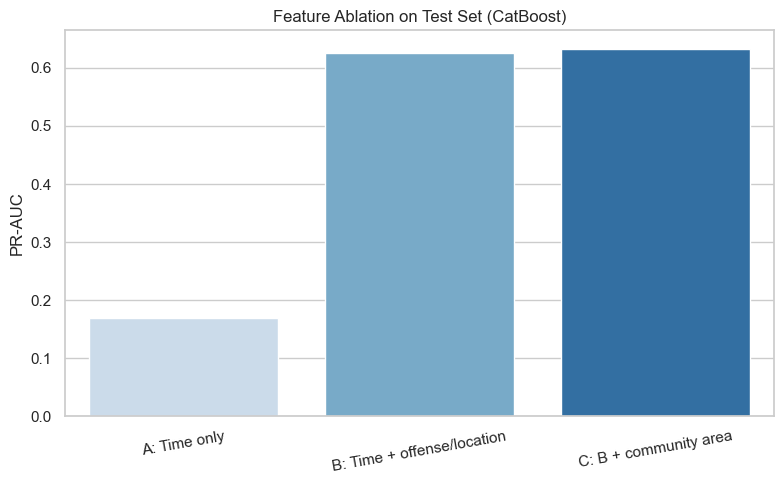

In [12]:
boosting_validation = pd.concat([
    lgb_results[lgb_results['Split'] == 'Validation'],
    xgb_results[xgb_results['Split'] == 'Validation'],
    cat_results[cat_results['Split'] == 'Validation'],
], ignore_index=True)
best_boosting_model_name = boosting_validation.sort_values('PR-AUC', ascending=False).iloc[0]['Model']
print('Best boosting model by validation PR-AUC:', best_boosting_model_name)

ablation_results_path = frame_path('ablation_results.csv')
ablation_meta = load_metadata().get('sections', {}).get('ablation', {})

ablation_feature_sets = {
    'A: Time only': ['Month', 'DayOfWeek', 'Hour'],
    'B: Time + offense/location': ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Domestic'],
    'C: B + community area': ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Domestic', 'Community Area'],
}

if ablation_results_path.exists() and ablation_meta.get('source_model') == best_boosting_model_name:
    ablation_results = load_frame(ablation_results_path)
else:
    if best_boosting_model_name == 'LightGBM':
        ablation_builder = build_lgb_model
        ablation_params = best_lgb_params
        ablation_imbalance = f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}"

        def ablation_fit_fn(model, sample, validation_payload):
            model.fit(
                prepare_lgb_frame(sample, validation_payload['features']),
                sample[TARGET].astype(int),
                categorical_feature=validation_payload['cat_features'],
                eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
                eval_metric='auc',
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )

        def ablation_score_fn(model, validation_payload):
            return (
                model.predict_proba(validation_payload['X_val'])[:, 1],
                model.predict_proba(validation_payload['X_test'])[:, 1],
            )

    elif best_boosting_model_name == 'XGBoost':
        ablation_builder = build_xgb_model
        ablation_params = best_xgb_params
        ablation_imbalance = f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}"

        def ablation_fit_fn(model, sample, validation_payload):
            model.fit(
                prepare_xgb_frame(sample, validation_payload['features'], category_maps),
                sample[TARGET].astype(int),
                eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
                verbose=False,
            )

        def ablation_score_fn(model, validation_payload):
            return (
                model.predict_proba(validation_payload['X_val'])[:, 1],
                model.predict_proba(validation_payload['X_test'])[:, 1],
            )

    else:
        ablation_builder = build_cat_model
        ablation_params = best_cat_params
        ablation_imbalance = f"auto_class_weights={best_cat_params['auto_class_weights']}"

        def ablation_fit_fn(model, sample, validation_payload):
            train_pool = Pool(
                prepare_cat_frame(sample, validation_payload['features']),
                sample[TARGET].astype(int),
                cat_features=validation_payload['cat_indices'],
            )
            val_pool = Pool(
                validation_payload['X_val'],
                validation_payload['y_val'],
                cat_features=validation_payload['cat_indices'],
            )
            model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)

        def ablation_score_fn(model, validation_payload):
            val_pool = Pool(validation_payload['X_val'], cat_features=validation_payload['cat_indices'])
            test_pool = Pool(validation_payload['X_test'], cat_features=validation_payload['cat_indices'])
            return (
                model.predict_proba(val_pool)[:, 1],
                model.predict_proba(test_pool)[:, 1],
            )

    ablation_rows = []
    for feature_set_name, feature_list in ablation_feature_sets.items():
        cat_subset = [col for col in CAT_FEATURES if col in feature_list]
        if best_boosting_model_name == 'LightGBM':
            payload = {
                'features': feature_list,
                'cat_features': cat_subset,
                'X_val': prepare_lgb_frame(val_full, feature_list),
                'X_test': prepare_lgb_frame(test_full, feature_list),
                'y_val': y_val,
            }
        elif best_boosting_model_name == 'XGBoost':
            payload = {
                'features': feature_list,
                'X_val': prepare_xgb_frame(val_full, feature_list, category_maps),
                'X_test': prepare_xgb_frame(test_full, feature_list, category_maps),
                'y_val': y_val,
            }
        else:
            cat_indices = [idx for idx, col in enumerate(feature_list) if col in ['Primary Type', 'Location Description', 'Community Area']]
            payload = {
                'features': feature_list,
                'cat_indices': cat_indices,
                'X_val': prepare_cat_frame(val_full, feature_list),
                'X_test': prepare_cat_frame(test_full, feature_list),
                'y_val': y_val,
            }

        ablation_artifact, ablation_attempts = fit_final_with_fallback(
            best_boosting_model_name,
            ablation_builder,
            ablation_params,
            train_full,
            ablation_fit_fn,
            payload,
        )
        model = ablation_artifact['model']
        val_scores, test_scores = ablation_score_fn(model, payload)
        threshold = choose_threshold(y_val, val_scores)
        ablation_rows.extend([
            evaluate_at_threshold(y_val, val_scores, threshold, best_boosting_model_name, f'{feature_set_name} | Validation', ablation_artifact['training_rows'], ablation_imbalance),
            evaluate_at_threshold(y_test, test_scores, threshold, best_boosting_model_name, f'{feature_set_name} | Test', ablation_artifact['training_rows'], ablation_imbalance),
        ])

    ablation_results = pd.DataFrame(ablation_rows)
    save_frame(ablation_results, ablation_results_path)
    metadata = update_section_metadata('ablation', {
        'results_file': ablation_results_path.name,
        'source_model': best_boosting_model_name,
    })

display(ablation_results[['Model', 'Split', 'Training Rows', 'Threshold', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']])

ablation_plot = ablation_results[ablation_results['Split'].str.contains('Test')].copy()
ablation_plot['Feature Set'] = ablation_plot['Split'].str.replace(' | Test', '', regex=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=ablation_plot, x='Feature Set', y='PR-AUC', hue='Feature Set', palette='Blues', legend=False)
plt.title(f'Feature Ablation on Test Set ({best_boosting_model_name})')
plt.ylabel('PR-AUC')
plt.xlabel('')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 11. Model Comparison and Final Findings

The final comparison table brings the modeling pieces together on a common out-of-time test window. The most important comparison is not whether every metric moves in the same direction, but whether the more flexible models deliver a consistent improvement in **test PR-AUC** over the linear baseline while preserving strong ranking performance.

In [13]:
all_results = pd.concat([logistic_results, rf_results, lgb_results, xgb_results, cat_results], ignore_index=True)
save_frame(all_results, frame_path('all_results.csv'))

display(all_results.sort_values(['Split', 'PR-AUC'], ascending=[True, False]))

main_comparison = all_results[all_results['Split'] == 'Test'].copy().sort_values('PR-AUC', ascending=False)
save_frame(main_comparison, frame_path('main_comparison.csv'))
display(main_comparison[['Model', 'Training Rows', 'Imbalance Handling', 'Threshold', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']])

best_model_row = main_comparison.iloc[0]
best_model_name = best_model_row['Model']
metadata = update_root_metadata({
    'best_model_name': best_model_name,
    'all_results_file': 'all_results.csv',
    'main_comparison_file': 'main_comparison.csv',
})

summary_md = chr(10).join([
    '### Final Findings',
    '',
    f"The strongest out-of-time test performance comes from **{best_model_name}**, which achieves a test PR-AUC of **{best_model_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_model_row['ROC-AUC']:.3f}**. This confirms that flexible tree-based ensembles extract substantially more predictive signal from the offense, setting, and spatial variables than the linear baseline.",
    '',
    'Across the model family, the overall pattern is stable. Logistic Regression remains a useful interpretable benchmark, but the boosted models deliver the clearest gains once non-linear interactions are allowed. Random Forest improves on the linear baseline, yet the boosting models remain more competitive on the primary PR-AUC criterion.',
    '',
    'Because the target is imbalanced, PR-AUC is the most policy-relevant headline metric in this project. The ranking of models on the final test window therefore supports the conclusion that boosted tree methods are better suited to this arrest prediction task than a purely linear specification.',
])
display(Markdown(summary_md))

,Model,Split,Threshold,Training Rows,Imbalance Handling,ROC-AUC,PR-AUC,F1,Precision,Recall
5,LightGBM,Test,0.572168,800000,scale_pos_weight=3.07,0.857140,0.633082,0.551969,0.699719,0.455738
9,CatBoost,Test,0.416412,800000,auto_class_weights=None,0.855756,0.632752,0.557510,0.684124,0.470442
7,XGBoost,Test,0.695827,800000,scale_pos_weight=4.04,0.856633,0.630958,0.556066,0.644547,0.488945
3,Random Forest,Test,0.431366,800000,class_weight=None,0.849394,0.624017,0.554357,0.688118,0.464135
1,Logistic Regression,Test,0.371541,800000,class_weight=None,0.832468,0.586297,0.511854,0.622781,0.434468
8,CatBoost,Validation,0.416412,800000,auto_class_weights=None,0.864188,0.620955,0.559080,0.664418,0.482571
4,LightGBM,Validation,0.572168,800000,scale_pos_weight=3.07,0.863348,0.616958,0.556305,0.672303,0.474445
6,XGBoost,Validation,0.695827,800000,scale_pos_weight=4.04,0.862840,0.616527,0.553876,0.621402,0.499586
2,Random Forest,Validation,0.431366,800000,class_weight=None,0.858028,0.612715,0.555898,0.664122,0.478003
0,Logistic Regression,Validation,0.371541,800000,class_weight=None,0.837578,0.570138,0.515432,0.582789,0.462031


,Model,Training Rows,Imbalance Handling,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall
5,LightGBM,800000,scale_pos_weight=3.07,0.572168,0.633082,0.857140,0.551969,0.699719,0.455738
9,CatBoost,800000,auto_class_weights=None,0.416412,0.632752,0.855756,0.557510,0.684124,0.470442
7,XGBoost,800000,scale_pos_weight=4.04,0.695827,0.630958,0.856633,0.556066,0.644547,0.488945
3,Random Forest,800000,class_weight=None,0.431366,0.624017,0.849394,0.554357,0.688118,0.464135
1,Logistic Regression,800000,class_weight=None,0.371541,0.586297,0.832468,0.511854,0.622781,0.434468


### Final Findings

The strongest out-of-time test performance comes from **LightGBM**, which achieves a test PR-AUC of **0.633** and a test ROC-AUC of **0.857**. This confirms that flexible tree-based ensembles extract substantially more predictive signal from the offense, setting, and spatial variables than the linear baseline.

Across the model family, the overall pattern is stable. Logistic Regression remains a useful interpretable benchmark, but the boosted models deliver the clearest gains once non-linear interactions are allowed. Random Forest improves on the linear baseline, yet the boosting models remain more competitive on the primary PR-AUC criterion.

Because the target is imbalanced, PR-AUC is the most policy-relevant headline metric in this project. The ranking of models on the final test window therefore supports the conclusion that boosted tree methods are better suited to this arrest prediction task than a purely linear specification.

## 12. SHAP Interpretability for the Best Model

Interpretability is reported for the **best-performing final model** rather than for every model in the notebook. This keeps the explanation aligned with the model that would actually be carried forward in a practical workflow and avoids turning SHAP into a second model-comparison exercise.

,Feature,Mean Absolute SHAP
3,Primary Type,0.628802
4,Location Description,0.288106
6,Community Area,0.080289
5,Domestic,0.071125
2,Hour,0.038617
0,Month,0.025068
1,DayOfWeek,0.002116


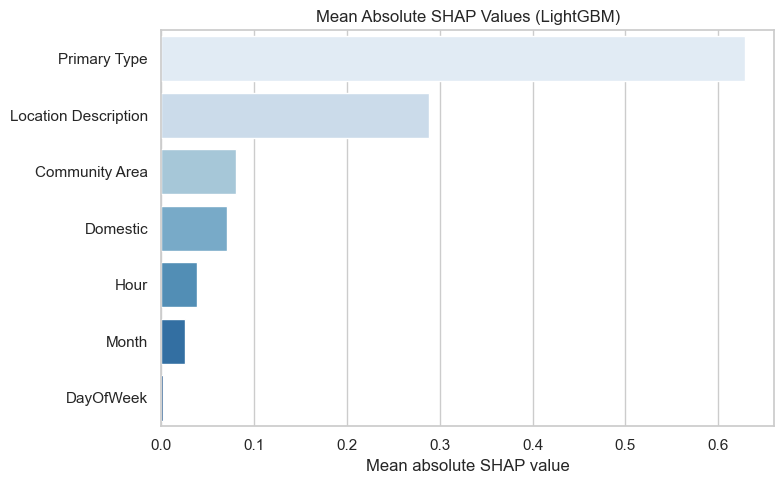

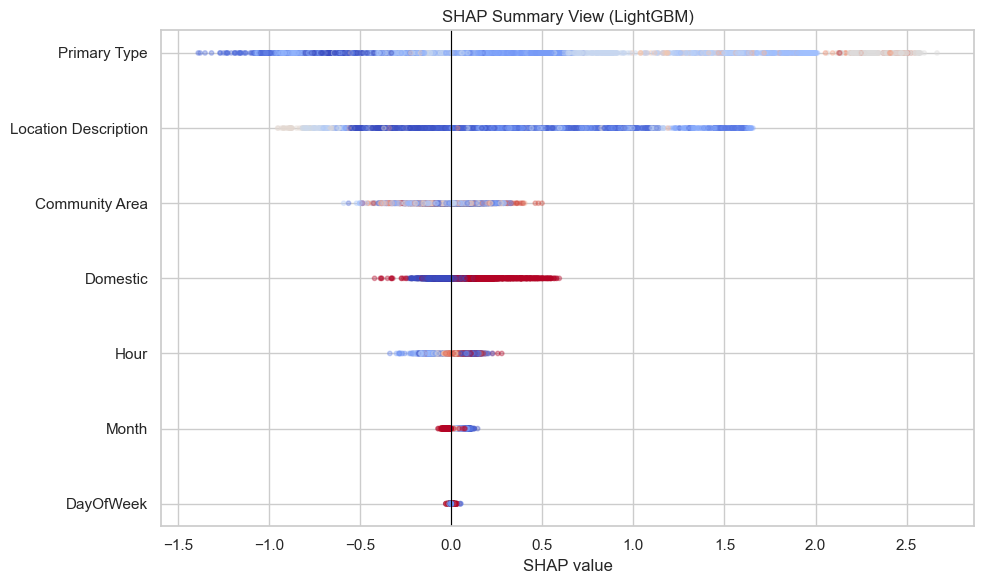

### SHAP Interpretation

For the best-performing final model, the SHAP analysis indicates that **Primary Type**, **Location Description**, and **Community Area** contribute the largest average shifts in predicted arrest probability. This result is substantively consistent with the earlier exploratory analysis: arrest outcomes are shaped primarily by offense type and incident setting, with additional signal coming from temporal and community-level context.

The SHAP results therefore reinforce the main modeling conclusion of the project. Arrest prediction in this dataset is not driven by time alone. Instead, the model relies most heavily on the combination of crime category, situational context, and geography, which together provide a structured explanation for why boosted models outperform the simpler baseline specification.

In [15]:
shap_importance_path = frame_path('best_model_shap_importance.csv')
shap_sample_path = frame_path('best_model_shap_sample.csv')
shap_values_path = frame_path('best_model_shap_values.npy')
shap_meta = load_metadata().get('sections', {}).get('shap', {})

if (
    shap_importance_path.exists()
    and shap_sample_path.exists()
    and shap_values_path.exists()
    and shap_meta.get('best_model') == best_model_name
):
    shap_importance = load_frame(shap_importance_path)
    shap_sample = load_frame(shap_sample_path)
    shap_feature_values = np.load(shap_values_path)
else:
    best_model = load_model_artifact(best_model_name)
    shap_sample_source = stratified_sample(test_full, min(SHAP_SAMPLE_ROWS, len(test_full)))

    if best_model_name == 'CatBoost':
        shap_sample = prepare_cat_frame(shap_sample_source, BASE_FEATURES)
        shap_pool = Pool(shap_sample, cat_features=cat_feature_indices)
        shap_values = best_model.get_feature_importance(shap_pool, type='ShapValues')
        shap_feature_values = shap_values[:, :-1]

    elif best_model_name == 'LightGBM':
        shap_sample = prepare_lgb_frame(shap_sample_source, BASE_FEATURES)
        shap_values = best_model.predict(shap_sample, pred_contrib=True)
        shap_feature_values = shap_values[:, :-1]

    else:
        raise NotImplementedError(
            f'SHAP section currently supports CatBoost and LightGBM only, got {best_model_name}.'
        )


    shap_importance = pd.DataFrame({
        'Feature': BASE_FEATURES,
        'Mean Absolute SHAP': np.abs(shap_feature_values).mean(axis=0),
    }).sort_values('Mean Absolute SHAP', ascending=False)

    save_frame(shap_importance, shap_importance_path)
    save_frame(shap_sample, shap_sample_path)
    np.save(shap_values_path, shap_feature_values)
    metadata = update_section_metadata('shap', {
        'best_model': best_model_name,
        'importance_file': shap_importance_path.name,
        'sample_file': shap_sample_path.name,
        'values_file': shap_values_path.name,
        'sample_rows': len(shap_sample),
    })

display(shap_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=shap_importance, x='Mean Absolute SHAP', y='Feature', hue='Feature', palette='Blues', legend=False)
plt.title(f'Mean Absolute SHAP Values ({best_model_name})')
plt.xlabel('Mean absolute SHAP value')
plt.ylabel('')
plt.tight_layout()
plt.show()

order = np.argsort(np.abs(shap_feature_values).mean(axis=0))[::-1]
ordered_features = [BASE_FEATURES[idx] for idx in order]
ordered_values = shap_feature_values[:, order]
ordered_sample = shap_sample[ordered_features]

plt.figure(figsize=(10, 6))
for rank, feature in enumerate(ordered_features[:7]):
    y_vals = ordered_values[:, rank]
    x_vals = ordered_sample[feature]
    if pd.api.types.is_numeric_dtype(x_vals):
        colors = x_vals.astype(float)
    else:
        colors = pd.factorize(x_vals)[0]
    y_jitter = y_vals + np.random.default_rng(RANDOM_STATE + rank).normal(0, 0.01, size=len(y_vals))
    plt.scatter(y_vals, np.full(len(y_vals), len(ordered_features[:7]) - rank), c=colors, cmap='coolwarm', alpha=0.35, s=10)
plt.yticks(range(1, len(ordered_features[:7]) + 1), ordered_features[:7][::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('SHAP value')
plt.title(f'SHAP Summary View ({best_model_name})')
plt.tight_layout()
plt.show()

top_features = shap_importance['Feature'].head(3).tolist()
shap_md = chr(10).join([
    '### SHAP Interpretation',
    '',
    f"For the best-performing final model, the SHAP analysis indicates that **{top_features[0]}**, **{top_features[1]}**, and **{top_features[2]}** contribute the largest average shifts in predicted arrest probability. This result is substantively consistent with the earlier exploratory analysis: arrest outcomes are shaped primarily by offense type and incident setting, with additional signal coming from temporal and community-level context.",
    '',
    'The SHAP results therefore reinforce the main modeling conclusion of the project. Arrest prediction in this dataset is not driven by time alone. Instead, the model relies most heavily on the combination of crime category, situational context, and geography, which together provide a structured explanation for why boosted models outperform the simpler baseline specification.',
])
display(Markdown(shap_md))